# PCA пример

In [19]:
# Установка зависимостей
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [20]:
import pandas as pd

In [21]:
# Загрузка датасета
df = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18t4_sleep.csv")

df.head()

,age,marital-status,gender,bmi,snoring-rate,respiration-rate,body-temperature,limb-movement,blood-oxygen,eye-movement,sleeping-hours,heart-rate
0,67.0,0,1,36.6,23.0,18.0,90.33,16.600,97.0,20.0,1.840,74.20
1,80.0,0,1,32.5,11.0,20.0,96.12,10.000,95.0,25.0,7.000,60.00
2,49.0,0,0,34.4,8.0,19.0,96.64,13.920,95.0,23.0,0.768,68.84
3,79.0,1,0,24.0,11.0,12.0,79.87,6.496,90.0,20.0,8.248,53.12
4,81.0,0,1,29.0,8.0,14.0,80.31,9.376,90.0,25.0,6.376,58.44


In [22]:
print(f'Размер датасета: {df.shape}')


print('\nПропуски в колонках:')
print(df.isnull().sum())

print('\nМинимальные, средние и максимальные значения признаков:')
print(df.describe().T[['min', 'mean', 'max']])

Размер датасета: (5000, 12)

Пропуски в колонках:
age                 0
marital-status      0
gender              0
bmi                 0
snoring-rate        0
respiration-rate    0
body-temperature    0
limb-movement       0
blood-oxygen        0
eye-movement        0
sleeping-hours      0
heart-rate          0
dtype: int64

Минимальные, средние и максимальные значения признаков:
                    min       mean     max
age                0.08  42.789176   82.00
marital-status     0.00   0.488800    1.00
gender             0.00   0.417800    1.00
bmi               11.30  27.503898   97.60
snoring-rate       0.00  20.566800   99.00
respiration-rate  10.00  16.324800   25.00
body-temperature  79.03  91.920722   99.30
limb-movement      0.00  11.669907   25.00
blood-oxygen      75.00  91.288154   99.00
eye-movement      20.00  28.657912  104.96
sleeping-hours     0.00   4.090151    9.00
heart-rate        50.00  65.547672   88.00


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

train_df, test_df = train_test_split(df, test_size=0.2, random_state=627)

transformer = Pipeline([
    ('scaler', StandardScaler())
])

train_scaled_values = transformer.fit_transform(train_df)
test_scaled_values = transformer.transform(test_df)
train_scaled = pd.DataFrame(train_scaled_values, columns=train_df.columns, index=train_df.index)

print('\nСтатистика преобразованных данных:')
print(train_scaled.describe().T[['min', 'mean', 'max']])


Статистика преобразованных данных:
                       min          mean       max
age              -1.896156  3.552714e-18  1.753956
marital-status   -0.980686 -7.815970e-17  1.019694
gender           -0.847039 -9.947598e-17  1.180583
bmi              -2.111744  2.273737e-16  9.192065
snoring-rate     -1.907947  1.751932e-16  7.256974
respiration-rate -1.937736  2.131628e-16  2.634553
body-temperature -2.883854 -2.131628e-17  1.644619
limb-movement    -2.683860  3.415046e-16  3.066319
blood-oxygen     -3.709030  7.682743e-17  1.760321
eye-movement     -0.477721 -1.776357e-17  4.284119
sleeping-hours   -1.313835  1.176836e-16  1.571866
heart-rate       -1.543742 -2.771117e-16  2.244557


In [27]:
from sklearn.decomposition import PCA

# Создаём объект класса PCA
pca = PCA(n_components=2)  # Оставим только 2 главные компоненты

# Обучаем PCA на данных
pca.fit(train_scaled_values)

# Преобразуем данные
X_train_pca_values = pca.transform(train_scaled_values)
X_test_pca_values = pca.transform(test_scaled_values)


# Дадим названия новым признакам
n_components = X_train_pca_values.shape[1]
columns = [f'PC{i+1}' for i in range(n_components)]

# Преобразуем в датасет
X_train_pca = pd.DataFrame(X_train_pca_values, columns=columns)

print(f'Старый размер датасета: {train_df.shape}\n')
print(f'Новый размер датасета: {X_train_pca.shape}\n')
print(X_train_pca.head())

Старый размер датасета: (4000, 12)

Новый размер датасета: (4000, 2)

        PC1       PC2
0 -2.853316 -0.660123
1 -0.755023 -0.973453
2 -2.855218 -0.638190
3 -2.245942 -0.068194
4  3.106593 -0.631611


In [40]:
# Создаём пайплайн: сначала масштабируем, потом выделяем главные компоненты
pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('pca', PCA(n_components=12))   
])

pipeline.fit(train_df)

# Преобразуем данные
X_train_pca_values = pipeline.transform(train_df)
X_test_pca_values = pipeline.transform(test_df)

n_components = X_train_pca_values.shape[1]
columns = [f'PC{i+1}' for i in range(n_components)]
X_train_pca = pd.DataFrame(X_train_pca_values, columns=columns)

print(f'Новый размер датасета после пайплайна: {X_train_pca.shape}\n')
print(X_train_pca.head())

Новый размер датасета после пайплайна: (4000, 12)

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -2.853316 -0.660123  0.766026  0.841207 -1.068854 -0.214550  0.474173   
1 -0.755023 -0.973453 -2.216745 -0.199869  1.001028 -0.916240  0.054657   
2 -2.855218 -0.638190 -0.189381  0.323170 -0.161802  1.509587  0.434184   
3 -2.245942 -0.068194 -0.377313 -1.087126  0.547005  0.010374  0.546468   
4  3.106593 -0.631611  0.455171 -0.549710 -0.335927 -0.673819 -0.970688   

        PC8       PC9      PC10      PC11      PC12  
0  1.113901 -0.080760  0.323137  0.138778  0.064280  
1 -1.616375 -1.410138  0.408476  0.085996 -0.359778  
2  1.294193 -0.210138  0.012978  0.020390 -0.076100  
3  0.204144 -1.608044  0.229532 -0.448863  0.241843  
4 -0.061346 -0.154917 -0.978594  0.141553  0.245999  


In [37]:
pipeline['pca'].explained_variance_ratio_

array([0.29843152, 0.10887599, 0.1002358 ])

In [42]:
import numpy as np 

explained_variance = pipeline['pca'].explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Оформим в виде таблицы
import pandas as pd
table = pd.DataFrame({
    'Количество компонент': range(1, len(cumulative_variance) + 1),
    'Суммарная объяснённая дисперсия': cumulative_variance
})
print(table)

    Количество компонент  Суммарная объяснённая дисперсия
0                      1                         0.298432
1                      2                         0.407308
2                      3                         0.507543
3                      4                         0.593396
4                      5                         0.675553
5                      6                         0.753390
6                      7                         0.825755
7                      8                         0.884326
8                      9                         0.930883
9                     10                         0.969393
10                    11                         0.992007
11                    12                         1.000000


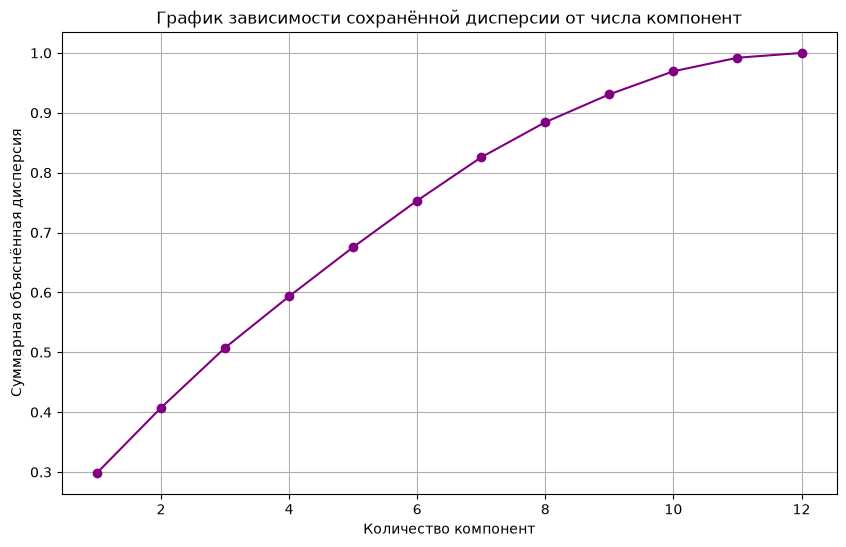

In [44]:
import numpy as np
import matplotlib.pyplot as plt

explained_variance = pipeline['pca'].explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='purple')
plt.xlabel('Количество компонент')
plt.ylabel('Суммарная объяснённая дисперсия')
plt.title('График зависимости сохранённой дисперсии от числа компонент')
plt.grid(True)
plt.show()